# REXAI Project - Session 1

## 1. Importing Libraries and Dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Data Exploration and Visualization

In [2]:
df = pd.read_csv("data/RH_dataset.csv", sep=";", encoding="utf-8")
df.head()

,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
0,Production,8.510000,7.900000,0.910000,0.970000,27,30,1,1,3199,Marié(e),0,32,0
1,Production,35.119999,22.690001,14.830000,16.299999,7,45,1,2,3861,Marié(e),1,1890,0
2,Production,25.299999,22.139999,17.309999,17.790001,28,49,1,2,4324,PACS,1,1847,0
3,Production,5.240000,5.100000,1.020000,1.750000,27,24,0,1,2641,Célibataire,0,2619,1
4,Production,35.919998,22.840000,8.050000,9.000000,7,46,1,2,5072,Marié(e),1,1963,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23857 entries, 0 to 23856
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Famille d'emploi              23857 non-null  str    
 1   Dernière promotion (mois)     23857 non-null  float64
 2   Dernière augmentation (mois)  23857 non-null  float64
 3   Début de contrat (années)     23857 non-null  float64
 4   Ancienneté groupe (années)    23857 non-null  float64
 5   Etablissement                 23857 non-null  int64  
 6   Âge (années)                  23857 non-null  int64  
 7   Parent                        23857 non-null  int64  
 8   Niveau hiérarchique           23857 non-null  int64  
 9   Salaire (Euros)               23857 non-null  int64  
 10  Statut marital                23857 non-null  str    
 11  Véhicule                      23857 non-null  int64  
 12  matricule                     23857 non-null  int64  
 13  label       

In [4]:
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns]# if c not in ["Etablissement"]]
cat_cols = list(df.select_dtypes(include=[str]).columns)# + ["Etablissement"]
assert len(num_cols) + len(cat_cols) == df.shape[1], "Some columns are not categorized correctly."

In [5]:
col_to_category = {}
for col in cat_cols:
    unique_values = df[col].unique().tolist()
    col_to_category[col] = unique_values
    print(f"Column: {col}, Unique Values: {unique_values}")

Column: Famille d'emploi, Unique Values: ['Production', 'Commercial/Business', 'Etudes & Technique', 'Support', 'IT', 'Développement Immobilier', 'Matériel/Equipement', 'Management']
Column: Statut marital, Unique Values: ['Marié(e)', 'PACS', 'Célibataire', 'Divorcé(e)', 'Union libre', 'Concubin', 'Séparé(e)', 'Veuf(ve)', 'ex PACS']


In [6]:
# Hot encoding for categorical variables
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False, dtype=int)
df_encoded.head()

,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Véhicule,...,Famille d'emploi_Support,Statut marital_Concubin,Statut marital_Célibataire,Statut marital_Divorcé(e),Statut marital_Marié(e),Statut marital_PACS,Statut marital_Séparé(e),Statut marital_Union libre,Statut marital_Veuf(ve),Statut marital_ex PACS
0,8.510000,7.900000,0.910000,0.970000,27,30,1,1,3199,0,...,0,0,0,0,1,0,0,0,0,0
1,35.119999,22.690001,14.830000,16.299999,7,45,1,2,3861,1,...,0,0,0,0,1,0,0,0,0,0
2,25.299999,22.139999,17.309999,17.790001,28,49,1,2,4324,1,...,0,0,0,0,0,1,0,0,0,0
3,5.240000,5.100000,1.020000,1.750000,27,24,0,1,2641,0,...,0,0,1,0,0,0,0,0,0,0
4,35.919998,22.840000,8.050000,9.000000,7,46,1,2,5072,1,...,0,0,0,0,1,0,0,0,0,0


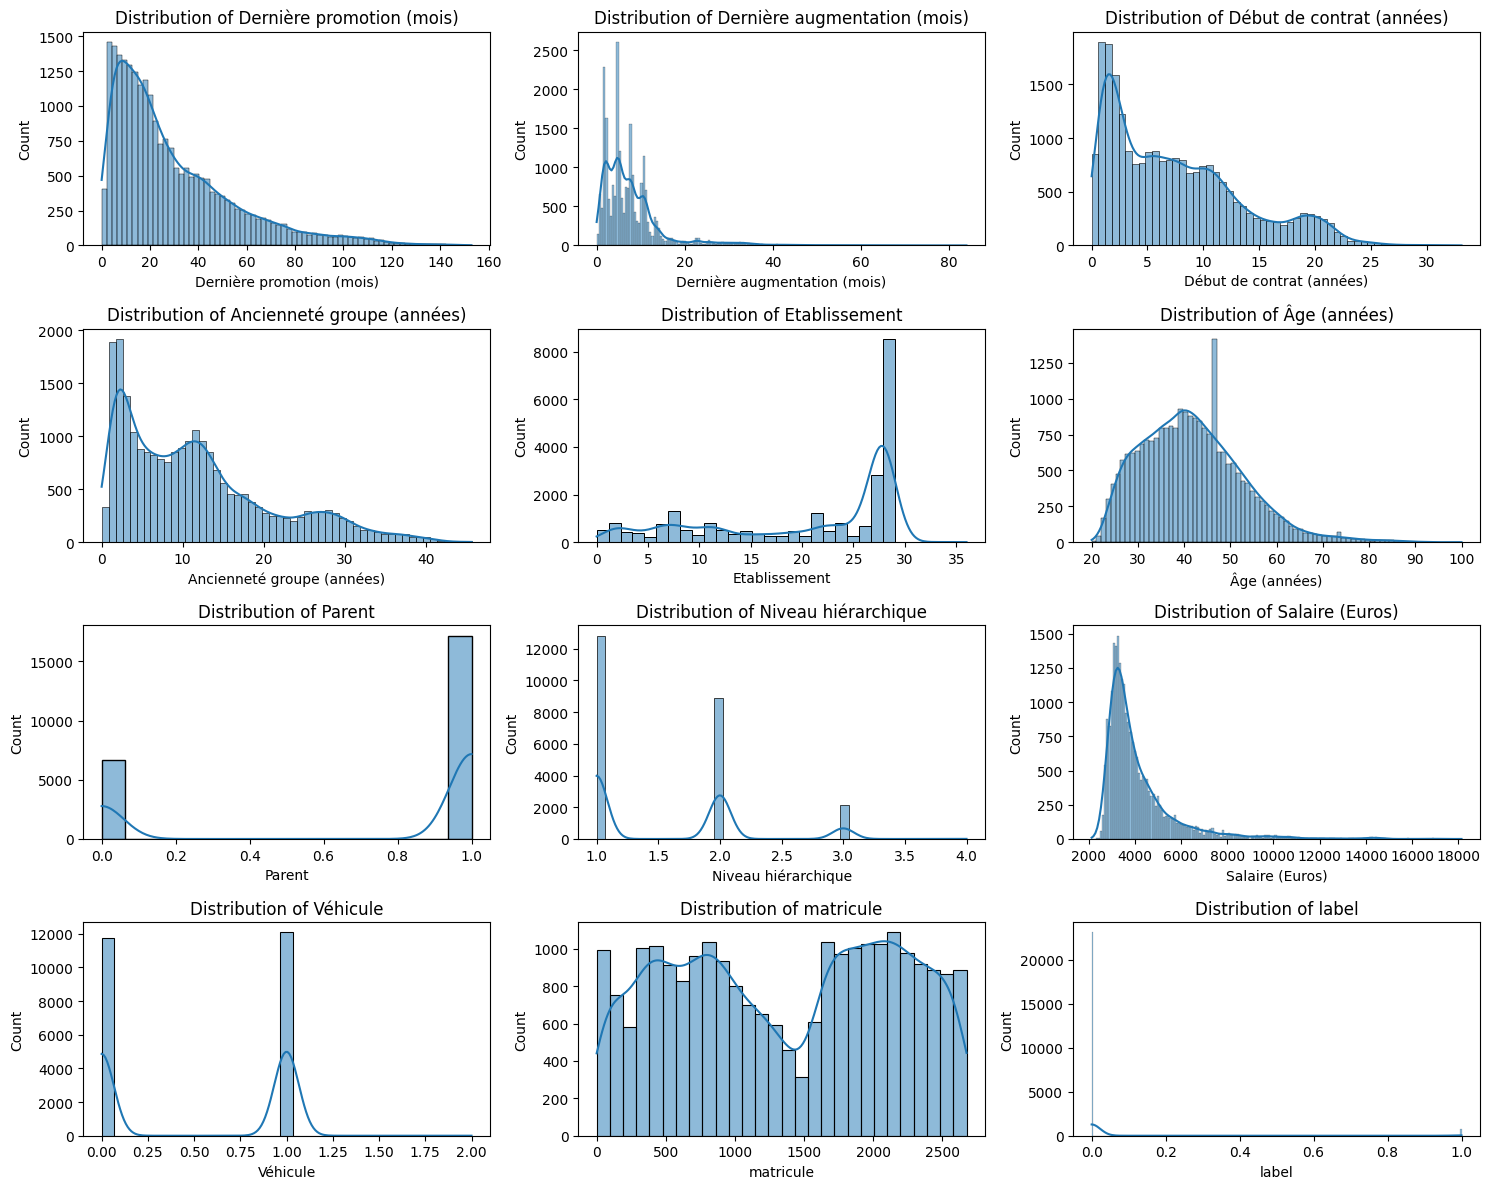

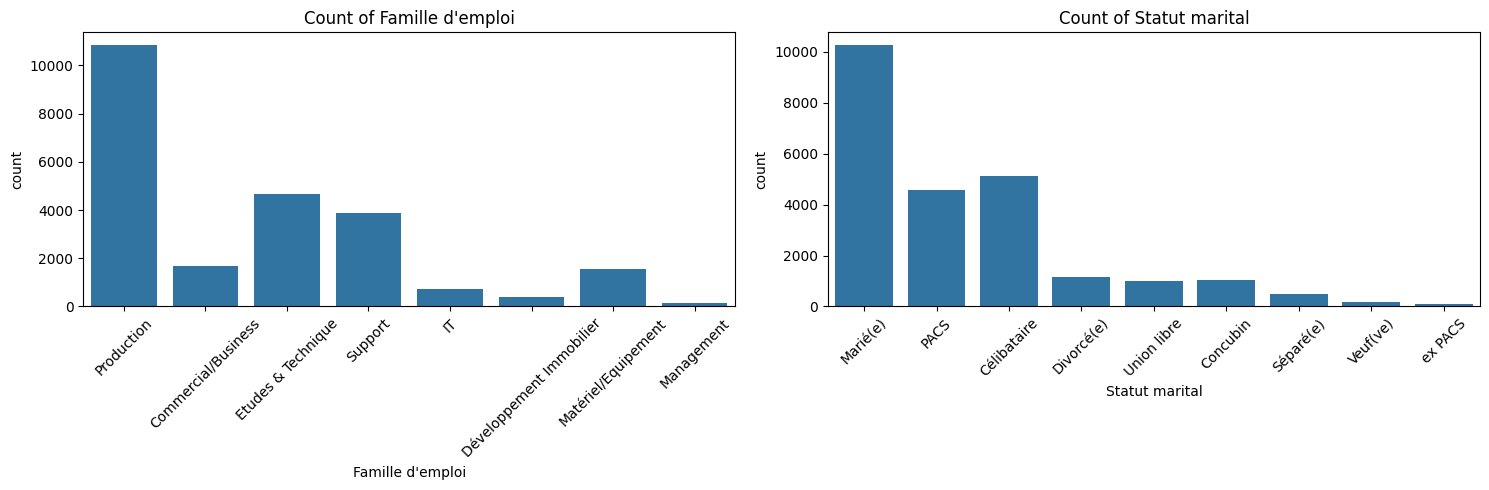

In [7]:
# Plot on the same figure in grid mode
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
axes = axes.flatten()  # Flatten the 2D array of axes to 1D for easy iteration
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

# Show histograms for categorical variables
fig, axes = plt.subplots(nrows=1, ncols=len(cat_cols), figsize=(15, 5))
for i, col in enumerate(cat_cols):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Count of {col}")
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Correlation Heatmap

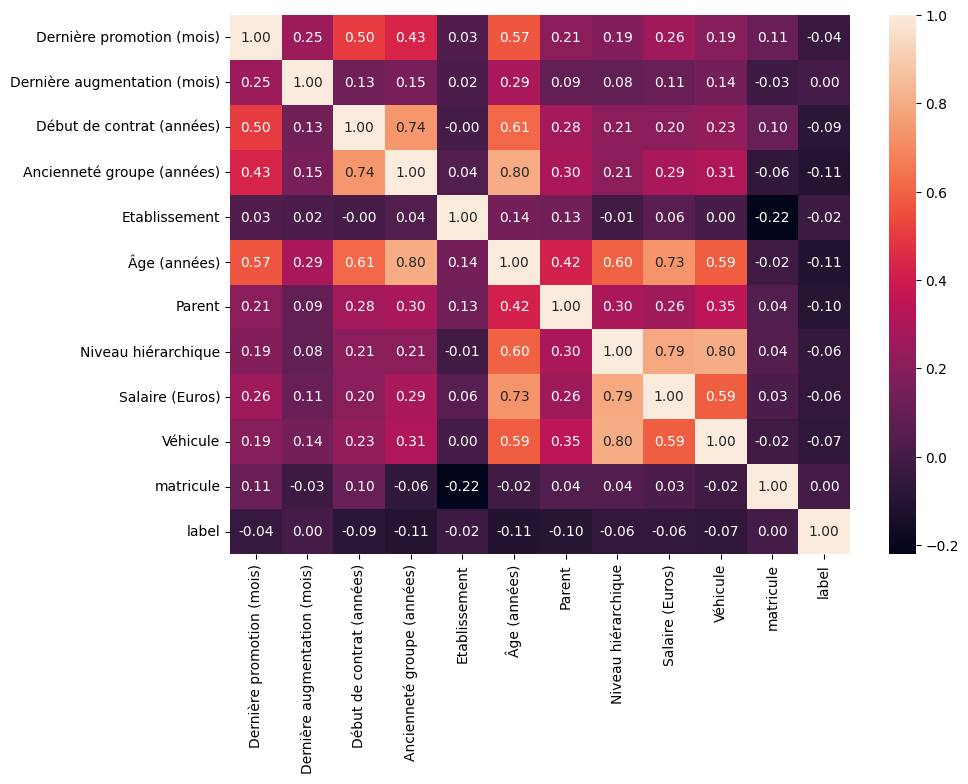

In [8]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f")
plt.show()

Let's analyze the first highest correlations by decreasing magnitude.

| Correlation | Variable 1 | Variable 2 | Comment |
|:-----------:|------------|------------|:--------|
| 0.80 | Ancienneté groupe | Âge | Older employees are likely to have more seniority in the group. |
| 0.80 | Véhicule | Niveau hiérarchique | This correlation might indicate that employees with higher hierarchical levels are more likely to have a vehicle provided by the company. |
| 0.79 | Salaire | Niveau hiérarchique | Higher hierarchical levels typically correspond to higher salaries, which explains this strong correlation. |
| 0.74 | Début du contrat | Ancienneté groupe | We could expect this correlation since the start of the contract is likely related to the seniority in the group. |
| 0.73 | Salaire | Âge | Older employees often have more experience and therefore higher salaries. |

Other additional less significant, but still interesting correlations include:
- Age is highly correlated to most of the variables
  - last promotion: seniors have less mobility
  - last raise: seniors have less often raises
  - parent: seniors are more likely to have children
  - vehicule: seniors are more likely to have a company car
  - ...
- On the contrary, last promotion date is correlated with
  - date of contract: employees with a recent contract are more likely to have a recent promotion
  - age: younger employees are more likely to have a recent promotion

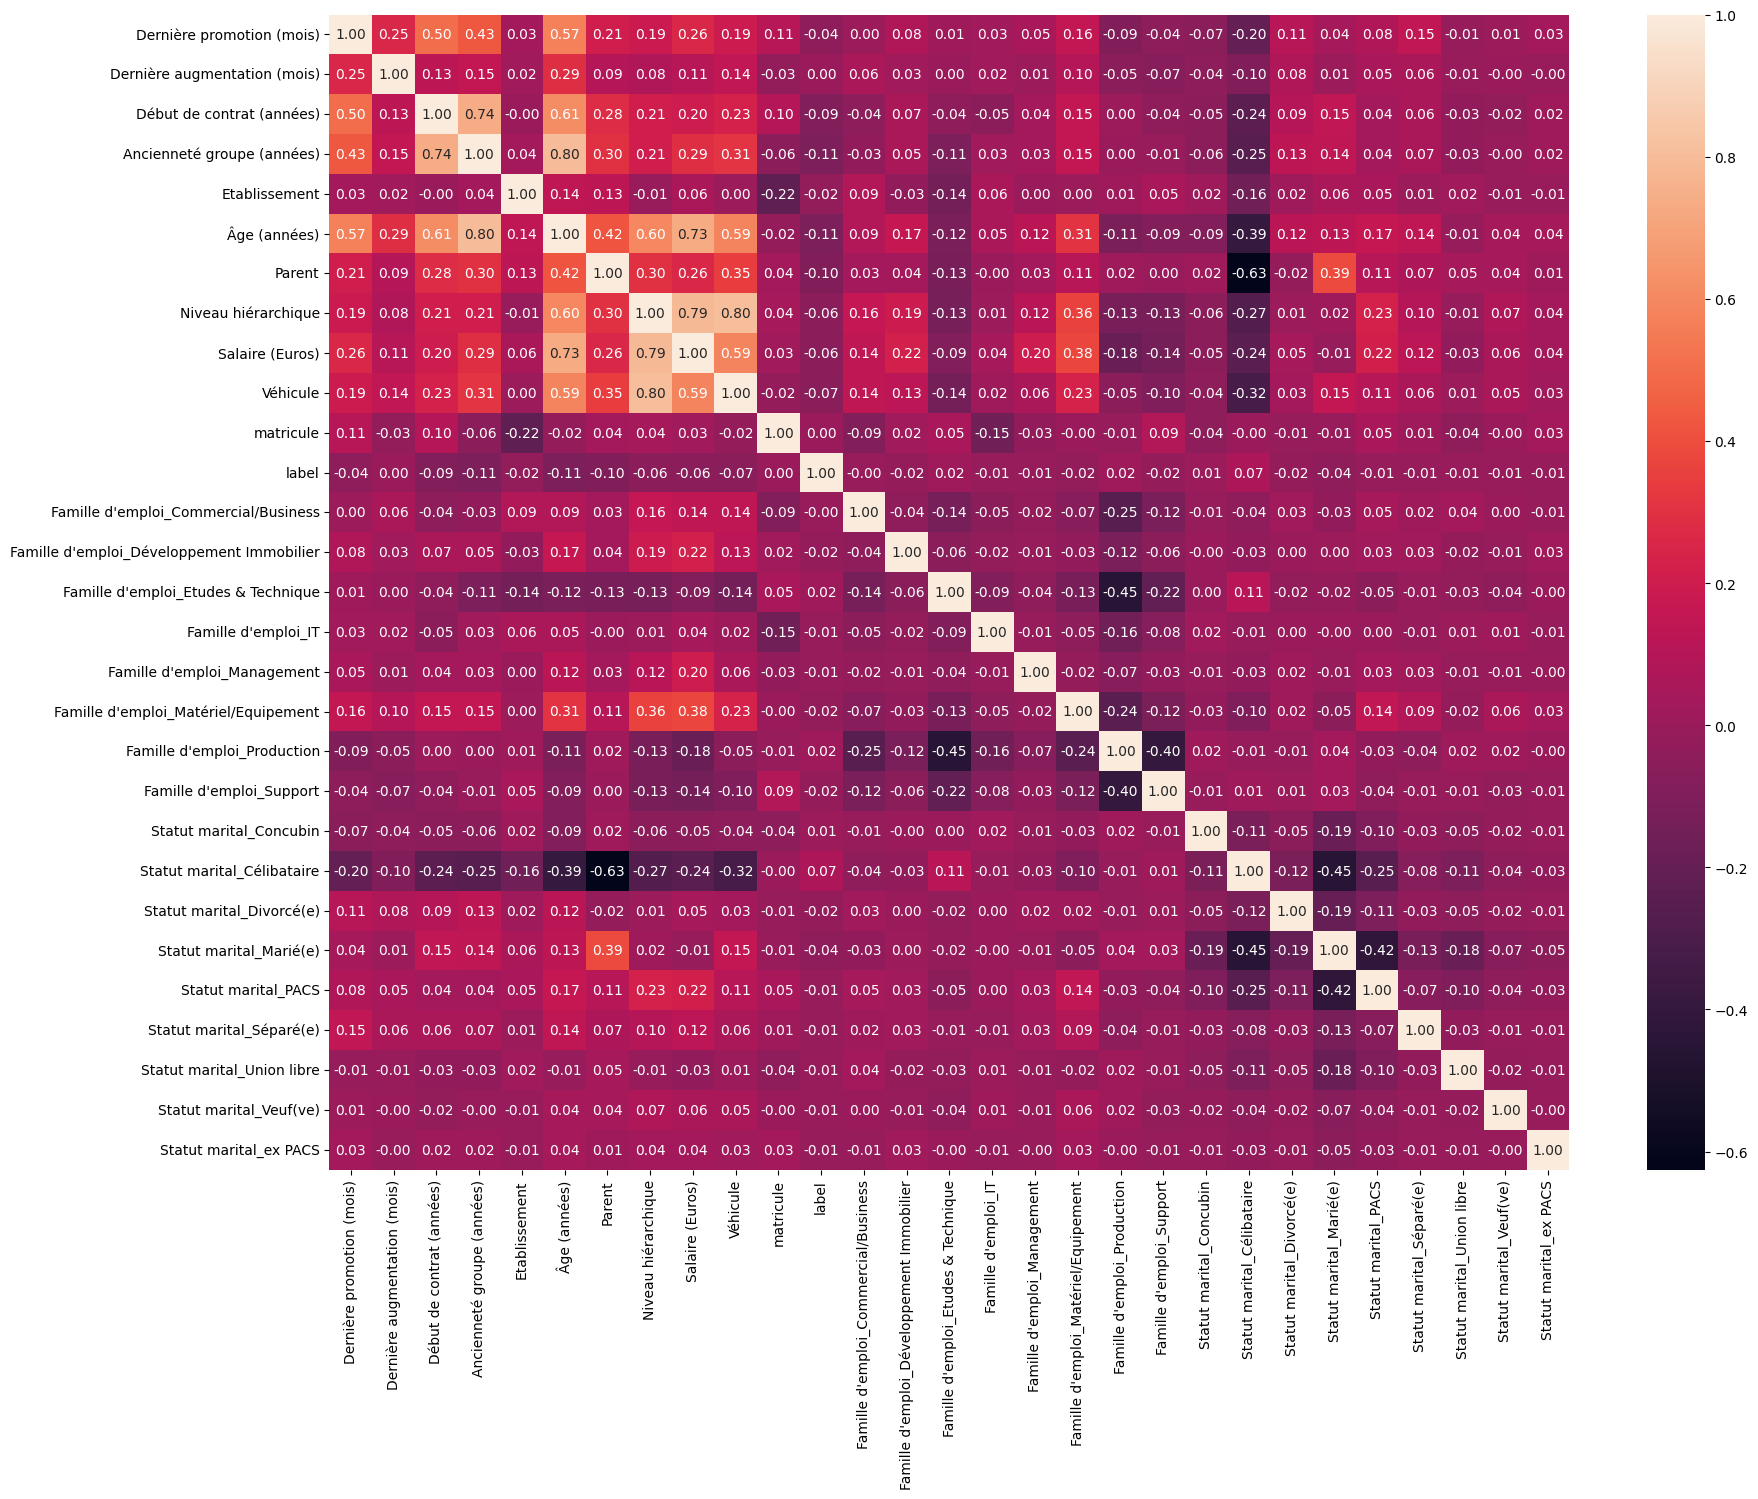

In [9]:
plt.figure(figsize=(20, 15))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f")
#sns.heatmap(df_etablissement_cat.corr(), annot=True, fmt=".2f")
plt.show()

By adding categorical variables, we can also see that:
- Material/Equipments employees are older, better paid and higher in the hierarchy than the other categories
- Single employees are younger, newer in the company, less paid and less likely to have a vehicle, and less likely to have children
- Married employees are more likely to have children (big surprise)
- Employees in PACS are older, better paid and at higher hierarchical levels

### 3.1.3. Training a GAM 

In [10]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop(columns=["label", "matricule"])
X = pd.get_dummies(X, columns=["Etablissement"], drop_first=False, dtype=int)
y = df_encoded["label"]

groups = df_encoded["matricule"]
splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
for train_idx, test_idx in splitter.split(X, y, groups=groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    groups_train = groups.iloc[train_idx]

class_counts = np.bincount(y_train)
class_weights = {0: 1.0, 1: class_counts[0] / class_counts[1]}
sample_weights = np.array([class_weights[label] for label in y_train])


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
from pygam import LinearGAM, s
from pygam.terms import TermList
import numpy as np

nb_val_per_col = [len(X[col].unique()) for col in X.columns]
s_v2 = lambda i, nb_val: s(i, n_splines=nb_val, spline_order=nb_val-1) if nb_val <= 10 else s(i)
gam_model = LinearGAM(TermList(*[s_v2(i, nb_val) for i, nb_val in enumerate(nb_val_per_col)]))
gam_model.fit(X_train_scaled, y_train.values, weights=sample_weights)
gam_model.summary()

# Compute metrics for GAM
gam_predictions = gam_model.predict(X_test_scaled)

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                    144.4226
Link Function:                     IdentityLink Log Likelihood:                               -141573.5593
Number of Samples:                        19132 AIC:                                           283437.9637
                                                AICc:                                          283440.2068
                                                GCV:                                                 0.367
                                                Scale:                                              0.6017
                                                Pseudo R-Squared:                                    0.605
Feature Function                  Lam

/tmp/ipykernel_1694983/1129693191.py:9: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam_model.summary()


GAM ROC AUC: 0.6953736583580648


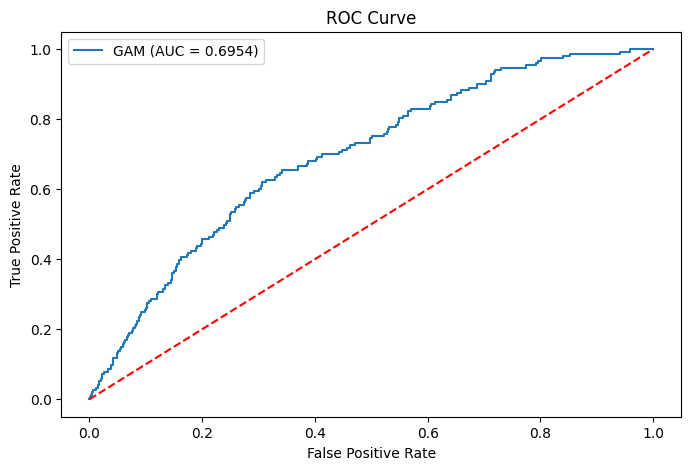

In [12]:
from sklearn.metrics import roc_auc_score, roc_curve
auc_score = roc_auc_score(y_test, gam_predictions)
print(f"GAM ROC AUC: {auc_score}")

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, gam_predictions)
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f'GAM (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.68      0.80      4572
           1       0.06      0.63      0.11       153

    accuracy                           0.68      4725
   macro avg       0.52      0.65      0.46      4725
weighted avg       0.95      0.68      0.78      4725



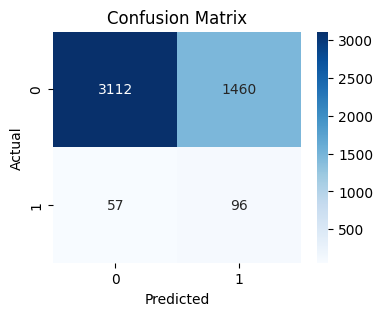

In [13]:
from sklearn.metrics import classification_report, confusion_matrix

threshold = 0.5
gam_pred_labels = (gam_predictions >= threshold).astype(int)

# Display classification report
print("Classification Report:")
print(classification_report(y_test, gam_pred_labels))

# Confusion matrix
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, gam_pred_labels), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

<Figure size 640x480 with 0 Axes>

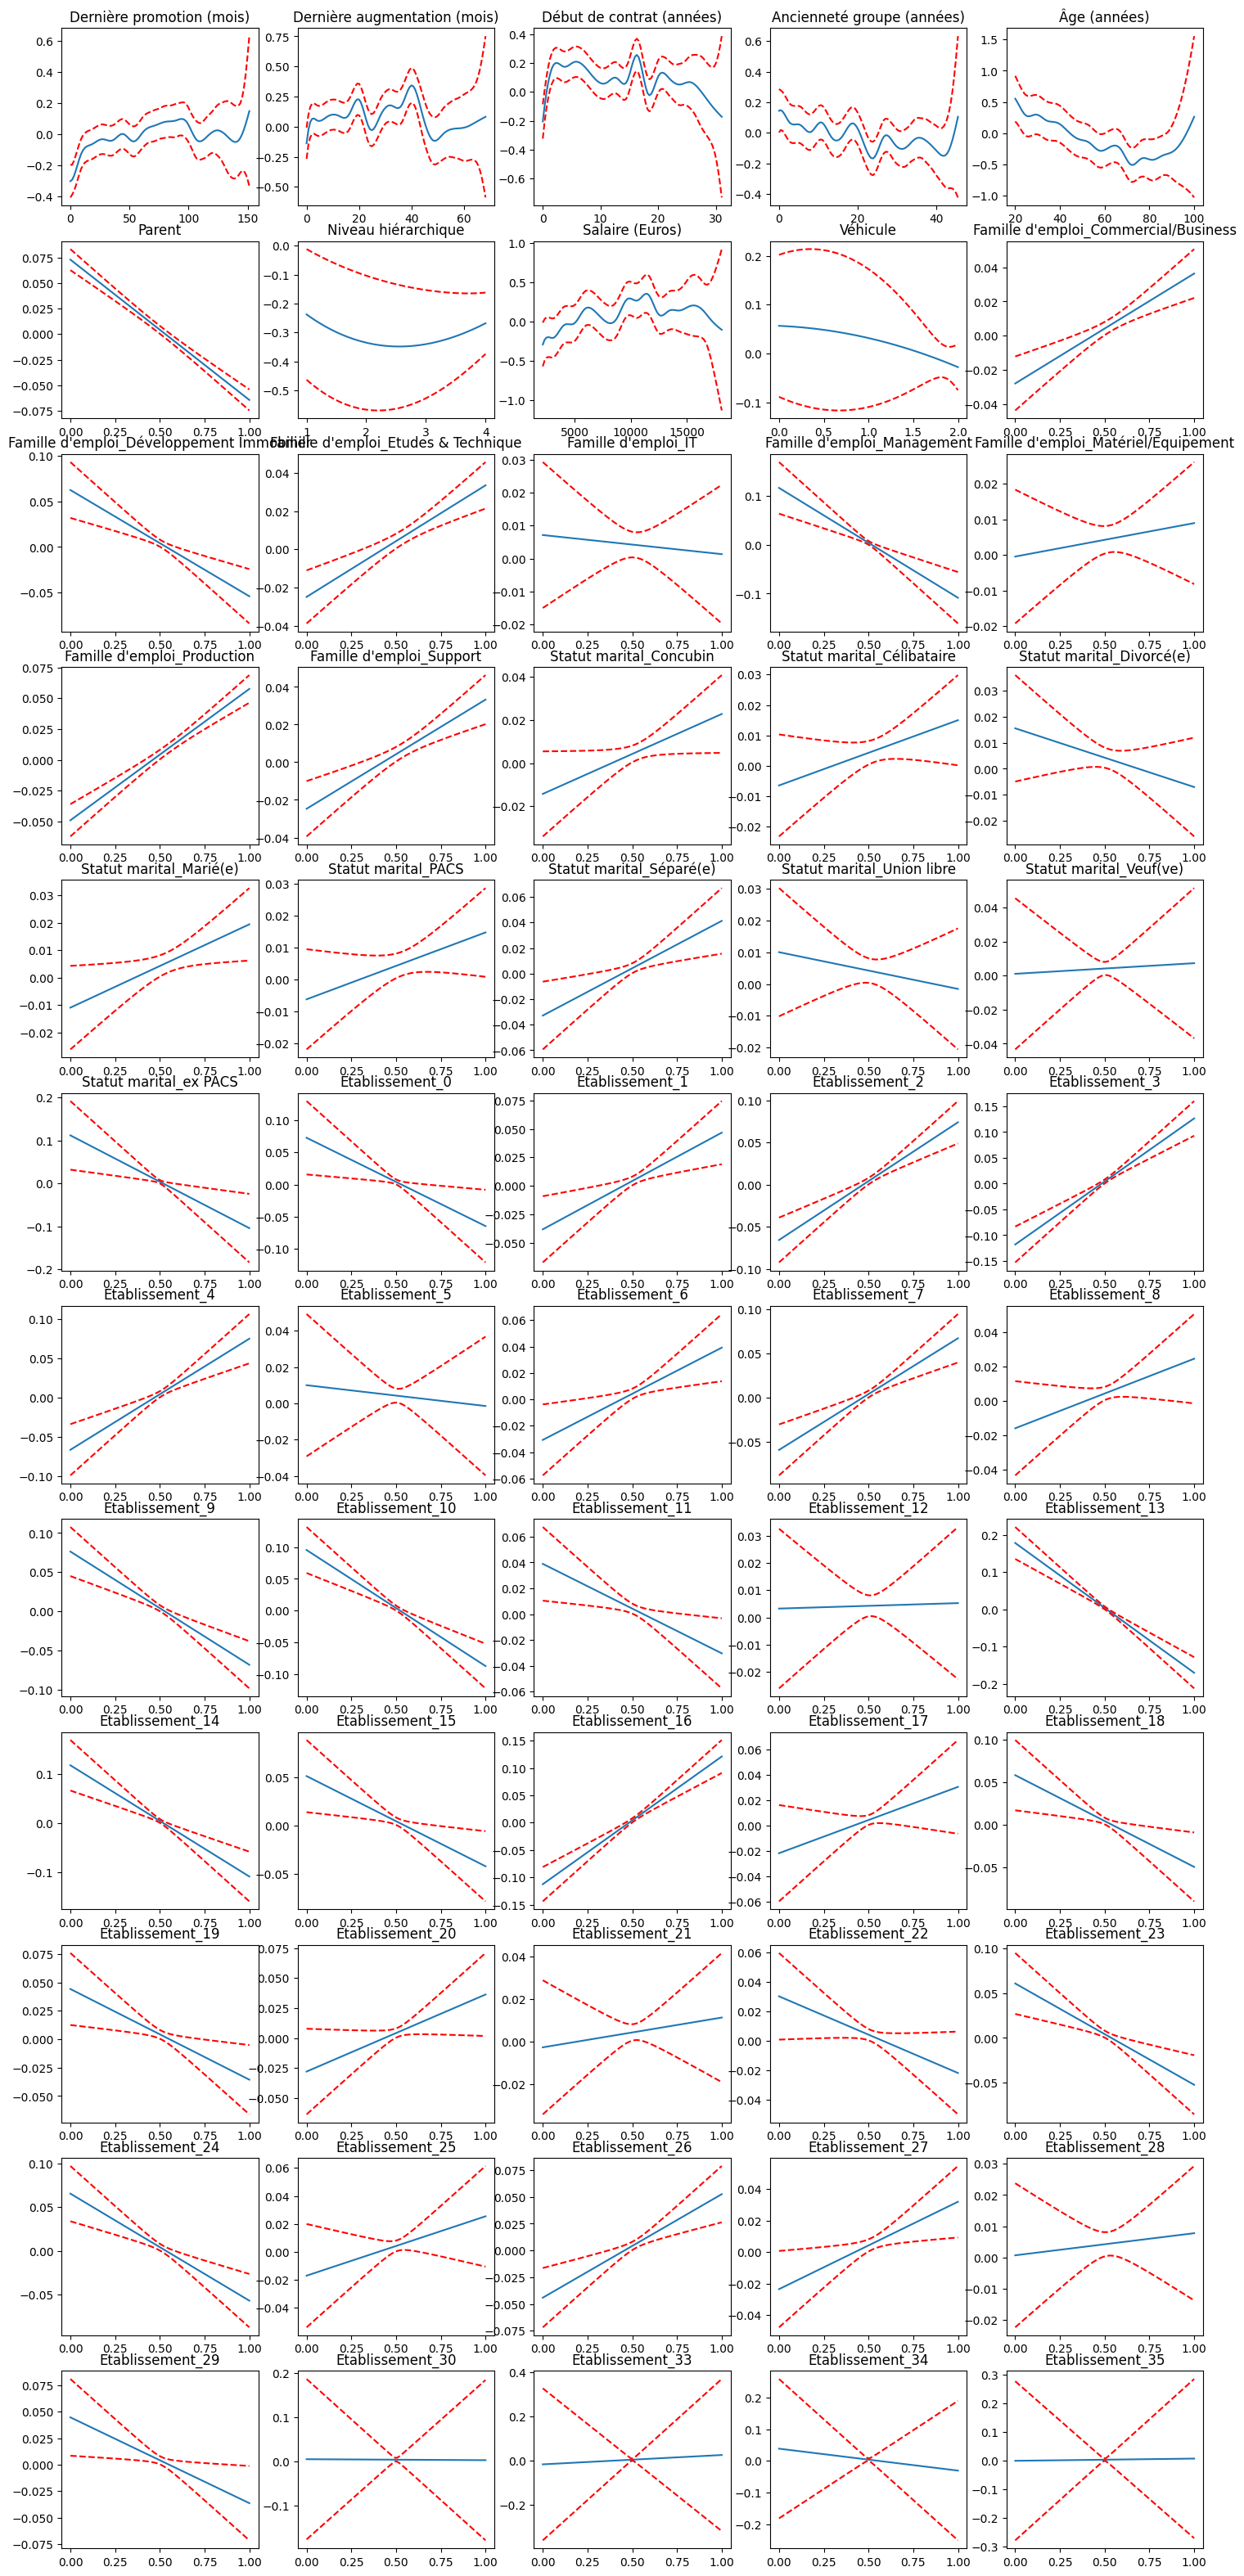

In [14]:
plt.figure()
fig, axs = plt.subplots(12, 5)
fig.set_size_inches(18, 40)
titles = X.columns.to_list()
for i, ax in enumerate(axs.flatten()):
    XX = gam_model.generate_X_grid(term=i)
    XX_descaled = scaler.inverse_transform(XX)
    ax.plot(XX_descaled[:, i], gam_model.partial_dependence(term=i, X=XX))
    ax.plot(
        XX_descaled[:, i], gam_model.partial_dependence(term=i, X=XX, width=0.95)[1], c="r", ls="--"
    )
    ax.set_title(titles[i])

In [15]:
p_value_threshold = 0.02
significant_vars = []
unsignificant_vars = []

for col, p_value in zip(X.columns, gam_model.statistics_["p_values"]):
    if p_value < p_value_threshold:
        significant_vars.append(col)
    else:
        unsignificant_vars.append(col)

print("Significant variables:", significant_vars)
print("Unsigificant variables:", unsignificant_vars)
print(f"Reducing the number of variables from {len(X.columns)} to {len(significant_vars)}")

Significant variables: ['Dernière promotion (mois)', 'Dernière augmentation (mois)', 'Début de contrat (années)', 'Ancienneté groupe (années)', 'Âge (années)', 'Parent', 'Niveau hiérarchique', 'Salaire (Euros)', "Famille d'emploi_Commercial/Business", "Famille d'emploi_Développement Immobilier", "Famille d'emploi_Etudes & Technique", "Famille d'emploi_Management", "Famille d'emploi_Production", "Famille d'emploi_Support", 'Statut marital_Séparé(e)', 'Etablissement_1', 'Etablissement_2', 'Etablissement_3', 'Etablissement_4', 'Etablissement_7', 'Etablissement_9', 'Etablissement_10', 'Etablissement_13', 'Etablissement_14', 'Etablissement_16', 'Etablissement_23', 'Etablissement_24', 'Etablissement_26']
Unsigificant variables: ['Véhicule', "Famille d'emploi_IT", "Famille d'emploi_Matériel/Equipement", 'Statut marital_Concubin', 'Statut marital_Célibataire', 'Statut marital_Divorcé(e)', 'Statut marital_Marié(e)', 'Statut marital_PACS', 'Statut marital_Union libre', 'Statut marital_Veuf(ve)',

In [16]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

X = pd.get_dummies(df_encoded, columns=["Etablissement"], drop_first=False, dtype=int)
X = X[significant_vars]
y = df_encoded["label"]

groups = df_encoded["matricule"]
splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
for train_idx, test_idx in splitter.split(X, y, groups=groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    groups_train = groups.iloc[train_idx]

class_counts = np.bincount(y_train)
class_weights = {0: 1.0, 1: class_counts[0] / class_counts[1]}
sample_weights = np.array([class_weights[label] for label in y_train])


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
from pygam import LinearGAM, s
from pygam.terms import TermList
import numpy as np

nb_val_per_col = [len(X[col].unique()) for col in X.columns]
s_v2 = lambda i, nb_val: s(i, n_splines=nb_val, spline_order=nb_val-1) if nb_val <= 10 else s(i)
gam_model_v2 = LinearGAM(TermList(*[s_v2(i, nb_val) for i, nb_val in enumerate(nb_val_per_col)]))
gam_model_v2.fit(X_train_scaled, y_train.values, weights=sample_weights)
gam_model_v2.summary()

# Compute metrics for GAM
gam_predictions = gam_model_v2.predict(X_test_scaled)

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                    114.2838
Link Function:                     IdentityLink Log Likelihood:                               -142187.3623
Number of Samples:                        19132 AIC:                                           284605.2923
                                                AICc:                                          284606.7023
                                                GCV:                                                0.3682
                                                Scale:                                              0.6035
                                                Pseudo R-Squared:                                   0.6019
Feature Function                  Lam

/tmp/ipykernel_1694983/987072111.py:9: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam_model_v2.summary()


GAM ROC AUC: 0.6857813116497693


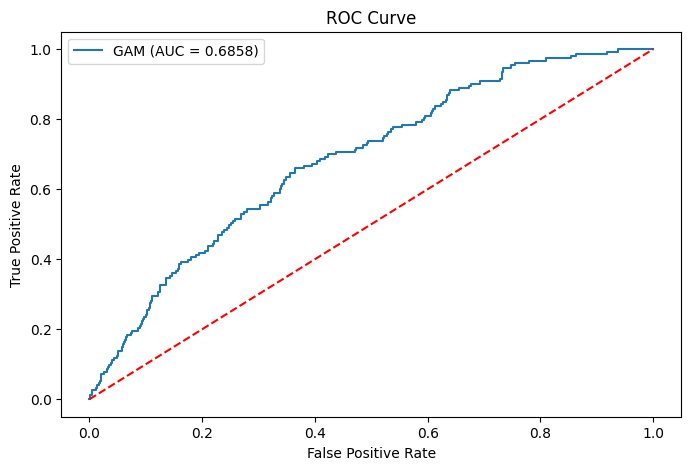

In [18]:
from sklearn.metrics import roc_auc_score, roc_curve
auc_score = roc_auc_score(y_test, gam_predictions)
print(f"GAM ROC AUC: {auc_score}")

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, gam_predictions)
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f'GAM (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.67      0.80      4572
           1       0.06      0.59      0.10       153

    accuracy                           0.67      4725
   macro avg       0.52      0.63      0.45      4725
weighted avg       0.95      0.67      0.77      4725



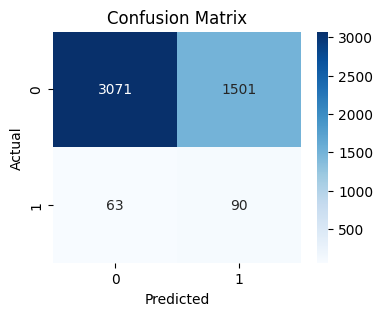

In [19]:
from sklearn.metrics import classification_report, confusion_matrix

threshold = 0.5
gam_pred_labels = (gam_predictions >= threshold).astype(int)

# Display classification report
print("Classification Report:")
print(classification_report(y_test, gam_pred_labels))

# Confusion matrix
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, gam_pred_labels), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [21]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

def fairness_evaluation_with_trueDI(y_true, y_pred, X, age_bins=[20,40,60,80,100]):    
    df_eval = X.copy()
    df_eval['y_true'] = y_true
    df_eval['y_pred'] = y_pred
    
    # Tranches d'âge
    age_labels = [f"{age_bins[i]}-{age_bins[i+1]}" for i in range(len(age_bins)-1)]
    df_eval['Âge (années)'] = pd.cut(df_eval['Âge (années)'], bins=age_bins, labels=age_labels)
    
    results = {}
    
    # Sous-groupes
    subgroups = {
        'Parent': df_eval['Parent'].unique(),
        'Âge (années)': df_eval['Âge (années)'].unique()
    }
    
    # Calcul metrics
    for group_col, groups in subgroups.items():
        metrics = []
        privileged_group = groups[0]  # référence pour DI
        
        for g in groups:
            sub = df_eval[df_eval[group_col]==g]
            if len(sub)==0:
                continue
            
            # FPR / FNR
            tn, fp, fn, tp = confusion_matrix(sub['y_true'], sub['y_pred'], labels=[0,1]).ravel()
            fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
            fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
            
            # Disparate Impact sur prédiction
            p_priv_pred = df_eval[df_eval[group_col]==privileged_group]['y_pred'].mean()
            p_unpriv_pred = sub['y_pred'].mean()
            di_pred = p_unpriv_pred / p_priv_pred if p_priv_pred > 0 else np.nan
            
            # Disparate Impact sur vrai label
            p_priv_true = df_eval[df_eval[group_col]==privileged_group]['y_true'].mean()
            p_unpriv_true = sub['y_true'].mean()
            di_true = p_unpriv_true / p_priv_true if p_priv_true > 0 else np.nan
            
            metrics.append({
                'group': g,
                'count': len(sub),
                'FPR': fpr,
                'FNR': fnr,
                'DI_pred': di_pred,
                'DI_true': di_true
            })
        
        results[group_col] = pd.DataFrame(metrics)
    
    return results

In [23]:
results = fairness_evaluation_with_trueDI(y_test, gam_pred_labels, X_test[['Parent','Âge (années)']])

for group_col, df_metrics in results.items():
    print(f"\n{group_col}")
    print(df_metrics.to_string(index=False))


Parent
 group  count      FPR      FNR  DI_pred  DI_true
     1   3508 0.220012 0.644444 1.000000 1.000000
     0   1217 0.649047 0.079365 2.967061 2.017749

Âge (années)
 group  count      FPR      FNR  DI_pred  DI_true
 20-40   2352 0.572190 0.178218 1.000000 1.000000
 60-80    257 0.019608 1.000000 0.033376 0.181223
 40-60   2070 0.102970 0.860000 0.178184 0.562491
80-100     46 0.000000      NaN 0.000000 0.000000
